# Kenya Coffee Research - Data Processing Pipeline
## Dataset: 1990-2024

**Project:** Predicting Coffee Yield Variation in Kenya Using Climate Data  
**Author:** Doreen Molly Wanjiru 
**Date:** 16 June 2026
**Dataset:** 35 years (1990-2024)

---

## Overview

This notebook processes:
1. Coffee yields data (FAOSTAT 1990-2024)
2. Coffee value data (FAOSTAT 1991-2024)
3. Regional climate data (NASA POWER 1990-2024, 8 regions)
4. Creates production-weighted national climate averages
5. Merges all data into final master dataset

---

## Data Sources

- **Coffee Data:** FAOSTAT (https://www.fao.org/faostat/)
- **Climate Data:** NASA POWER (https://power.larc.nasa.gov/)
- **Documentation:** See `data/DATA_SOURCES.md`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("KENYA COFFEE RESEARCH - DATA PROCESSING")
print("-"*40)
print(f"Run Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("✓ Libraries loaded successfully!")

KENYA COFFEE RESEARCH - DATA PROCESSING
----------------------------------------
Run Date: 2026-07-16 10:55
✓ Libraries loaded successfully!


---

# Part 1: Process Coffee Yields Data

**Source:** FAOSTAT - Production > Crops and livestock products  
**Period:** 1990-2024  
**Variables:**
- Area harvested (hectares)
- Production (tonnes)
- Yield (kg/ha)

In [2]:
# Load raw yields data
yields_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/raw/coffee_details/FAOSTAT_raw_data.csv'
yields_raw = pd.read_csv(yields_path)

print(f" Raw data loaded: {yields_raw.shape}")
print(f"\n Unique Elements:")
print(yields_raw['Element'].unique())

 Raw data loaded: (105, 15)

 Unique Elements:
['Area harvested' 'Yield' 'Production']


In [3]:
yields_filtered = yields_raw[yields_raw['Element'].isin([
    'Yield',
    'Production',
    'Area harvested'
])].copy()

yields_clean = yields_filtered[['Year', 'Element', 'Unit', 'Value']].copy()

yields_pivot = yields_clean.pivot_table(
    index='Year',
    columns='Element',
    values='Value'
).reset_index()

yields_pivot.columns.name = None

yields_pivot = yields_pivot.rename(columns={
    'Area harvested': 'Area_Ha',
    'Production': 'Production_Tonnes',
    'Yield': 'Yield_Kg_Ha'
})

print(f" Coffee yields cleaned:")
print(f"   Years: {yields_pivot['Year'].min()}-{yields_pivot['Year'].max()}")
print(f"   Total years: {len(yields_pivot)}")

 Coffee yields cleaned:
   Years: 1990-2024
   Total years: 35


In [4]:
print("First 10 rows:")
yields_pivot.head(10)

First 10 rows:


,Year,Area_Ha,Production_Tonnes,Yield_Kg_Ha
0,1990,153100.0,103900.0,678.6
1,1991,155400.0,86400.0,556.0
2,1992,153800.0,85300.0,554.6
3,1993,158200.0,75100.0,474.7
4,1994,158700.0,79900.0,503.5
5,1995,160500.0,95400.0,594.4
6,1996,177400.0,97976.0,552.3
7,1997,176907.0,68642.0,388.0
8,1998,178500.0,53715.0,300.9
9,1999,170000.0,68100.0,400.6


In [5]:
missing = yields_pivot.isnull().sum()
if missing.sum() > 0:
    print(" Missing values:")
    print(missing[missing > 0])
else:
    print("No missing values")

output_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/yields_clean_1990_2024.csv'
yields_pivot.to_csv(output_path, index=False)
print(f" Saved: {output_path}")

No missing values
 Saved: /Users/dwanjiru/projects/kenya-coffee-research/data/processed/yields_clean_1990_2024.csv


---

# Part 2: Process Coffee Value Data

**Source:** FAOSTAT - Value of Agricultural Production  
**Period:** 1990-2024   
**Variable:** Gross Production Value (constant 2014-2016 thousand US$)

In [6]:
value_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/raw/coffee_details/coffee_value_raw.csv'
value_raw = pd.read_csv(value_path)

print(f"Raw data loaded: {value_raw.shape}")

value_clean = value_raw[['Year', 'Value', 'Unit']].copy()
value_clean = value_clean.rename(columns={
    'Value': 'Production_Value_1000USD',
    'Unit': 'Value_Unit'
})

print(f"Coffee value cleaned:")
print(f"   Years: {value_clean['Year'].min()}-{value_clean['Year'].max()}")
print(f"   Total years: {len(value_clean)}")

Raw data loaded: (35, 14)
Coffee value cleaned:
   Years: 1990-2024
   Total years: 35


In [7]:
print("All rows:")
value_clean.head(100)

All rows:


,Year,Production_Value_1000USD,Value_Unit
0,1990,425834,1000 USD
1,1991,354110,1000 USD
2,1992,349602,1000 USD
3,1993,307797,1000 USD
4,1994,327470,1000 USD
5,1995,390996,1000 USD
6,1996,401554,1000 USD
7,1997,281329,1000 USD
8,1998,220151,1000 USD
9,1999,279108,1000 USD


In [8]:
output_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/value_clean_1990_2024.csv'
value_clean.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: /Users/dwanjiru/projects/kenya-coffee-research/data/processed/value_clean_1990_2024.csv


---

# Part 3: Process Regional Climate Data

**Source:** NASA POWER Project  
**Regions:** 8 major coffee-producing counties  
**Period:** 1990-2024  
**Variables:**
- Temperature (°C)
- Precipitation (mm/day)
- Relative Humidity (%)
- Solar Radiation (MJ/m²/day)

## Regional Coverage

| Region | County | Production Share | Climate Zone |
|--------|--------|------------------|--------------|
| Nyeri | Nyeri | 15% | Central Highlands |
| Kirinyaga | Kirinyaga | 12% | Central |
| Murang'a | Murang'a | 10% | Central |
| Kiambu | Kiambu | 3% | Central |
| Embu | Embu | 15% | Eastern |
| Meru | Meru | 15% | Eastern |
| Kisii | Kisii | 15% | Western |
| Nakuru | Nakuru | 10% | Rift Valley |

**Total Coverage:** 95% of Kenya's coffee production

In [9]:
# Define regions and production weights
regions_info = {
    'Nyeri': {'file': 'Nyeri_raw_data.csv', 'production_share': 0.15, 'zone': 'Central'},
    'Kirinyaga': {'file': 'Kirinyaga_raw_data.csv', 'production_share': 0.12, 'zone': 'Central'},
    'Muranga': {'file': 'Muranga_raw_data.csv', 'production_share': 0.10, 'zone': 'Central'},
    'Kiambu': {'file': 'Kiambu_raw_data.csv', 'production_share': 0.03, 'zone': 'Central'},
    'Embu': {'file': 'Embu_raw_data.csv', 'production_share': 0.15, 'zone': 'Eastern'},
    'Meru': {'file': 'Meru_raw_data.csv', 'production_share': 0.15, 'zone': 'Eastern'},
    'Kisii': {'file': 'Kisii_raw_data.csv', 'production_share': 0.15, 'zone': 'Western'},
    'Nakuru': {'file': 'Nakuru_raw_data.csv', 'production_share': 0.10, 'zone': 'Rift Valley'}
}

total_coverage = sum([info['production_share'] for info in regions_info.values()])
print(f"Regions: {len(regions_info)}")
print(f"Total production coverage: {total_coverage*100:.0f}%")

climate_base_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/raw/climate_regional/'

Regions: 8
Total production coverage: 95%


In [10]:
def process_nasa_power_file(filepath, region_name):
    """Process NASA POWER CSV format (skips header, processes monthly data)"""
    
    df = pd.read_csv(filepath, skiprows=12)
    
    param_rename = {
        'T2M': 'Temperature',
        'PRECTOTCORR': 'Precipitation',
        'RH2M': 'Humidity',
        'ALLSKY_SFC_SW_DWN': 'Solar_Radiation'
    }
    df['PARAMETER'] = df['PARAMETER'].replace(param_rename)
    
    df_filtered = df[df['PARAMETER'].isin([
        'Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation'
    ])].copy()
    
    df_long = pd.melt(
        df_filtered,
        id_vars=['PARAMETER', 'YEAR'],
        value_vars=['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
                    'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'],
        var_name='Month',
        value_name='Value'
    )
    
    df_pivot = df_long.pivot_table(
        index=['YEAR', 'Month'],
        columns='PARAMETER',
        values='Value'
    ).reset_index()
    
    df_pivot.columns.name = None
    df_pivot = df_pivot.rename(columns={'YEAR': 'Year'})
    df_pivot['Region'] = region_name
    
    return df_pivot

print("Processing function defined")

Processing function defined


In [11]:
def process_nasa_power_file(filepath, region_name):
    """
    Process NASA POWER CSV files (wide format with monthly columns)
    """
    # Read the file, skipping header lines
    df = pd.read_csv(filepath, 
                     skiprows=16,  # Skip up to -END HEADER-
                     sep=',')
    
    print(f"      Columns found: {df.columns.tolist()}")
    
    # The data is in wide format: PARAMETER, YEAR, JAN, FEB, ..., DEC, ANN
    # We need to reshape it to long format
    
    # Drop the ANN column if present (we'll calculate averages ourselves)
    if 'ANN' in df.columns:
        df = df.drop('ANN', axis=1)
    
    # Melt from wide to long format
    id_vars = ['PARAMETER', 'YEAR']
    month_cols = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 
                  'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
    
    df_long = df.melt(id_vars=id_vars, 
                      value_vars=month_cols,
                      var_name='Month', 
                      value_name='Value')
    
    # Pivot so each parameter becomes a column
    df_pivoted = df_long.pivot_table(
        index=['YEAR', 'Month'],
        columns='PARAMETER',
        values='Value'
    ).reset_index()
    
    # Rename columns
    df_pivoted.columns.name = None
    df_pivoted = df_pivoted.rename(columns={'YEAR': 'Year'})
    
    # Convert month names to numbers
    month_map = {'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
                 'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12}
    df_pivoted['Month'] = df_pivoted['Month'].map(month_map)
    
    # Replace -999 with NaN
    df_pivoted = df_pivoted.replace(-999, pd.NA)
    
    # Add region
    df_pivoted['Region'] = region_name
    
    # Rename columns to more friendly names
    column_rename = {
        'ALLSKY_SFC_SW_DWN': 'Solar_Radiation',
        'GWETROOT': 'Root_Zone_Moisture',
        'GWETTOP': 'Surface_Moisture',
        'PRECTOTCORR': 'Precipitation',
        'QV2M': 'Humidity',
        'T2M': 'Temperature',
        'TS': 'Skin_Temperature',
        'WS2M': 'Wind_Speed'
    }
    df_pivoted = df_pivoted.rename(columns=column_rename)
    
    return df_pivoted

In [12]:
print("Loading regional climate data...\n")

all_regional_data = []

for region, info in regions_info.items():
    filepath = climate_base_path + info['file']
    
    if os.path.exists(filepath):
        try:
            df = process_nasa_power_file(filepath, region)
            df['Production_Weight'] = info['production_share']
            df['Zone'] = info['zone']
            all_regional_data.append(df)
            print(f"   ✓ {region:12s}: {len(df):4d} records ({df['Year'].min():.0f}-{df['Year'].max():.0f})")
        except Exception as e:
            print(f"   ✗ {region:12s}: Error - {e}")
    else:
        print(f"   ✗ {region:12s}: File not found")

print(f"\nLoaded {len(all_regional_data)}/8 regions")

# Combine all regions
if all_regional_data:
    climate_df = pd.concat(all_regional_data, ignore_index=True)
    print(f"\nTotal climate records: {len(climate_df)}")
    print(f"Columns: {climate_df.columns.tolist()}")
    print(f"\nSample:\n{climate_df.head()}")

Loading regional climate data...

      Columns found: ['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']
   ✓ Nyeri       :  432 records (1990-2025)
      Columns found: ['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']
   ✓ Kirinyaga   :  432 records (1990-2025)
      Columns found: ['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']
   ✓ Muranga     :  432 records (1990-2025)
      Columns found: ['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']
   ✓ Kiambu      :  432 records (1990-2025)
      Columns found: ['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']
   ✓ Embu        :  432 records (1990-2025)
      Columns found: ['PARAMETER', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY'

In [13]:
# Combine all regional data
if len(all_regional_data) > 0:
    regional_combined = pd.concat(all_regional_data, ignore_index=True)
    
    print(f"Regional data combined:")
    print(f"   Total records: {len(regional_combined):,}")
    print(f"   Regions: {regional_combined['Region'].nunique()}")
    print(f"   Years: {regional_combined['Year'].min()}-{regional_combined['Year'].max()}")
    
    # Save
    output_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/regional_climate_combined.csv'
    regional_combined.to_csv(output_path, index=False)
    print(f"\nSaved: {output_path}")
else:
    print(" No regional data loaded!")
    regional_combined = None

Regional data combined:
   Total records: 3,456
   Regions: 8
   Years: 1990-2025

Saved: /Users/dwanjiru/projects/kenya-coffee-research/data/processed/regional_climate_combined.csv


In [14]:
if regional_combined is not None:
    print("Sample of combined regional data:")
    print(regional_combined.head(10))

Sample of combined regional data:
   Year  Month Solar_Radiation  Root_Zone_Moisture  Surface_Moisture  Precipitation  Humidity  Temperature  Skin_Temperature  Wind_Speed Region  Production_Weight     Zone
0  1990      4           19.07                0.65              0.70           8.79     12.58        16.34             17.03        2.11  Nyeri               0.15  Central
1  1990      8           15.36                0.51              0.56           1.82     10.13        14.36             15.59        2.09  Nyeri               0.15  Central
2  1990     12           20.05                0.53              0.59           4.26     11.02        15.13             15.82        2.33  Nyeri               0.15  Central
3  1990      2           20.55                0.49              0.55           1.63     11.36        16.51             17.37        1.87  Nyeri               0.15  Central
4  1990      1           21.37                0.57              0.62           2.62     10.54        14.88

---

# Part 4: Create National Weighted Average

Using **production-weighted averaging** to create a national climate dataset:

$$\text{National Climate} = \frac{\sum(\text{Regional Climate} \times \text{Production Share})}{\sum \text{Production Share}}$$

This ensures regions that produce more coffee have proportionally greater influence on the national average.

In [15]:
# Create national weighted average (monthly)
if regional_combined is not None:
    climate_vars = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']
    
    print("Calculating production-weighted averages...\n")
    
    national_monthly_list = []
    
    for (year, month), group in regional_combined.groupby(['Year', 'Month']):
        record = {'Year': year, 'Month': month}
        
        for var in climate_vars:
            if var in group.columns:
                weighted_avg = (group[var] * group['Production_Weight']).sum() / group['Production_Weight'].sum()
                record[var] = weighted_avg
        
        national_monthly_list.append(record)
    
    national_monthly = pd.DataFrame(national_monthly_list)
    
    print(f"National monthly climate created:")
    print(f"   Records: {len(national_monthly)}")
    print(f"   Years: {national_monthly['Year'].min()}-{national_monthly['Year'].max()}")
    
    # Save
    output_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/national_climate_monthly_1990_2024.csv'
    national_monthly.to_csv(output_path, index=False)
    print(f"\nSaved: {output_path}")

Calculating production-weighted averages...

National monthly climate created:
   Records: 432
   Years: 1990-2025

Saved: /Users/dwanjiru/projects/kenya-coffee-research/data/processed/national_climate_monthly_1990_2024.csv


In [16]:
# Preview monthly data
if 'national_monthly' in locals():
    print("First 12 months:")
    print(national_monthly.head(12))

First 12 months:
    Year  Month  Temperature  Precipitation   Humidity  Solar_Radiation
0   1990      1    17.339053       2.521263  11.015368        21.744316
1   1990      2    18.975263       2.749053  11.806316        21.031368
2   1990      3    18.619368       7.685474  12.720421        20.993368
3   1990      4    18.361684       8.640211  13.255368        19.754632
4   1990      5    18.012526       3.489789  12.680105        20.464737
5   1990      6    16.905263       0.926947  11.002737        19.066105
6   1990      7    16.494737       1.821158  10.182842        17.738105
7   1990      8    16.987158       2.145263  10.307368        17.503158
8   1990      9    18.080632       1.714105  10.053474        21.582842
9   1990     10    18.556000       3.696737  11.137263        20.712526
10  1990     11    18.082211       5.523474  12.147263        21.183263
11  1990     12    17.483474       3.585579  11.480421        20.458947


## Aggregate to Annual

For modeling, we aggregate monthly climate data to annual:

- **Temperature:** Annual average
- **Precipitation:** Annual sum (total rainfall)
- **Humidity:** Annual average
- **Solar Radiation:** Annual average

In [17]:
# Aggregate to annual
if 'national_monthly' in locals():
    national_yearly = national_monthly.groupby('Year').agg({
        'Temperature': 'mean',
        'Precipitation': 'sum',
        'Humidity': 'mean',
        'Solar_Radiation': 'mean'
    }).reset_index()
    
    print(f"National annual climate:")
    print(f"   Years: {national_yearly['Year'].min()}-{national_yearly['Year'].max()}")
    print(f"   Total years: {len(national_yearly)}")
    
    # Save
    output_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/national_climate_yearly_1990_2024.csv'
    national_yearly.to_csv(output_path, index=False)
    print(f"\nSaved: {output_path}")

National annual climate:
   Years: 1990-2025
   Total years: 36

Saved: /Users/dwanjiru/projects/kenya-coffee-research/data/processed/national_climate_yearly_1990_2024.csv


In [18]:
# Display annual climate data
if 'national_yearly' in locals():
    print("Summary statistics:")
    print(national_yearly.describe().round(2))
    print("\nFirst 10 years:")
    print(national_yearly.head(10))

Summary statistics:
          Year  Temperature  Precipitation  Humidity  Solar_Radiation
count    36.00        36.00          36.00     36.00            36.00
mean   2007.50        18.48          40.80     11.27            20.53
std      10.54         0.37          10.08      0.49             0.47
min    1990.00        17.82          22.30     10.13            18.82
25%    1998.75        18.28          36.07     11.00            20.23
50%    2007.50        18.46          39.97     11.22            20.53
75%    2016.25        18.73          44.90     11.54            20.84
max    2025.00        19.20          66.52     12.58            21.32

First 10 years:
   Year  Temperature  Precipitation   Humidity  Solar_Radiation
0  1990    17.824781      44.499053  11.482412        20.186114
1  1991    18.320640      36.424737  10.948439        20.751605
2  1992    18.271351      35.836526  10.859395        20.537921
3  1993    17.989491      38.086526  10.878316        20.632009
4  1994    18

---

# Part 5: Merge All Datasets

**Final step:** Merging coffee production + value + climate into one master dataset

In [19]:
# Merge all datasets
if 'national_yearly' in locals():
    print("Merging datasets...")
    
    # Step 1: Yields + Value
    merged_step1 = yields_pivot.merge(value_clean, on='Year', how='inner')
    print(f"   After yields + value: {merged_step1.shape}")
    
    # Step 2: Add Climate
    merged_final = merged_step1.merge(national_yearly, on='Year', how='inner')
    print(f"   After adding climate: {merged_final.shape}")
    
    print(f"\nFINAL MERGED DATASET:")
    print(f"   Shape: {merged_final.shape}")
    print(f"   Years: {merged_final['Year'].min()}-{merged_final['Year'].max()}")
    print(f"   Total observations: {len(merged_final)}")
    print(f"   Improvement: +{len(merged_final) - 21} years vs original (67% more data!)")

Merging datasets...
   After yields + value: (35, 6)
   After adding climate: (35, 10)

FINAL MERGED DATASET:
   Shape: (35, 10)
   Years: 1990-2024
   Total observations: 35
   Improvement: +14 years vs original (67% more data!)


In [20]:
# Check data quality
if 'merged_final' in locals():
    print("Columns:")
    for i, col in enumerate(merged_final.columns, 1):
        print(f"   {i}. {col}")
    
    # Missing values
    missing = merged_final.isnull().sum()
    if missing.sum() > 0:
        print(f"\n Missing values:")
        print(missing[missing > 0])
    else:
        print(f"\n No missing values!")

Columns:
   1. Year
   2. Area_Ha
   3. Production_Tonnes
   4. Yield_Kg_Ha
   5. Production_Value_1000USD
   6. Value_Unit
   7. Temperature
   8. Precipitation
   9. Humidity
   10. Solar_Radiation

 No missing values!


In [21]:
# Display final dataset
if 'merged_final' in locals():
    print("First 10 rows:")
    print(merged_final.head(10))

First 10 rows:
   Year   Area_Ha  Production_Tonnes  Yield_Kg_Ha  Production_Value_1000USD Value_Unit  Temperature  Precipitation   Humidity  Solar_Radiation
0  1990  153100.0           103900.0        678.6                    425834   1000 USD    17.824781      44.499053  11.482412        20.186114
1  1991  155400.0            86400.0        556.0                    354110   1000 USD    18.320640      36.424737  10.948439        20.751605
2  1992  153800.0            85300.0        554.6                    349602   1000 USD    18.271351      35.836526  10.859395        20.537921
3  1993  158200.0            75100.0        474.7                    307797   1000 USD    17.989491      38.086526  10.878316        20.632009
4  1994  158700.0            79900.0        503.5                    327470   1000 USD    18.279465      44.731053  11.013044        21.080351
5  1995  160500.0            95400.0        594.4                    390996   1000 USD    17.978833      41.650316  11.286921  

In [22]:
# Summary statistics
if 'merged_final' in locals():
    print("Summary Statistics:")
    print(merged_final.describe().round(2))

Summary Statistics:
          Year    Area_Ha  Production_Tonnes  Yield_Kg_Ha  Production_Value_1000USD  Temperature  Precipitation  Humidity  Solar_Radiation
count    35.00      35.00              35.00        35.00                     35.00        35.00          35.00     35.00            35.00
mean   2007.00  144453.49           57604.86       398.61                 236093.29        18.48          40.48     11.26            20.58
std      10.25   26679.29           20177.14       109.41                  82695.93         0.38          10.03      0.48             0.37
min    1990.00  108200.00           34500.00       262.50                 141398.00        17.82          22.30     10.13            20.01
25%    1998.50  114350.00           43250.00       311.15                 177260.00        18.28          35.99     10.99            20.28
50%    2007.00  155400.00           49500.00       370.00                 202876.00        18.46          39.83     11.18            20.54
75%    

In [23]:
# Save final master dataset
if 'merged_final' in locals():
    output_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/master_data_1990_2024.csv'
    merged_final.to_csv(output_path, index=False)
    print(f"SAVED FINAL DATASET: {output_path}")

SAVED FINAL DATASET: /Users/dwanjiru/projects/kenya-coffee-research/data/processed/master_data_1990_2024.csv


---

# Part 6: Data Visualization

Creating comprehensive visualizations to understand:
1. Trends in coffee production over time
2. Trends in climate variables
3. Relationships between climate and coffee yields

✓ Saved: /Users/dwanjiru/projects/kenya-coffee-research/reports/data_overview_1990_2024.png


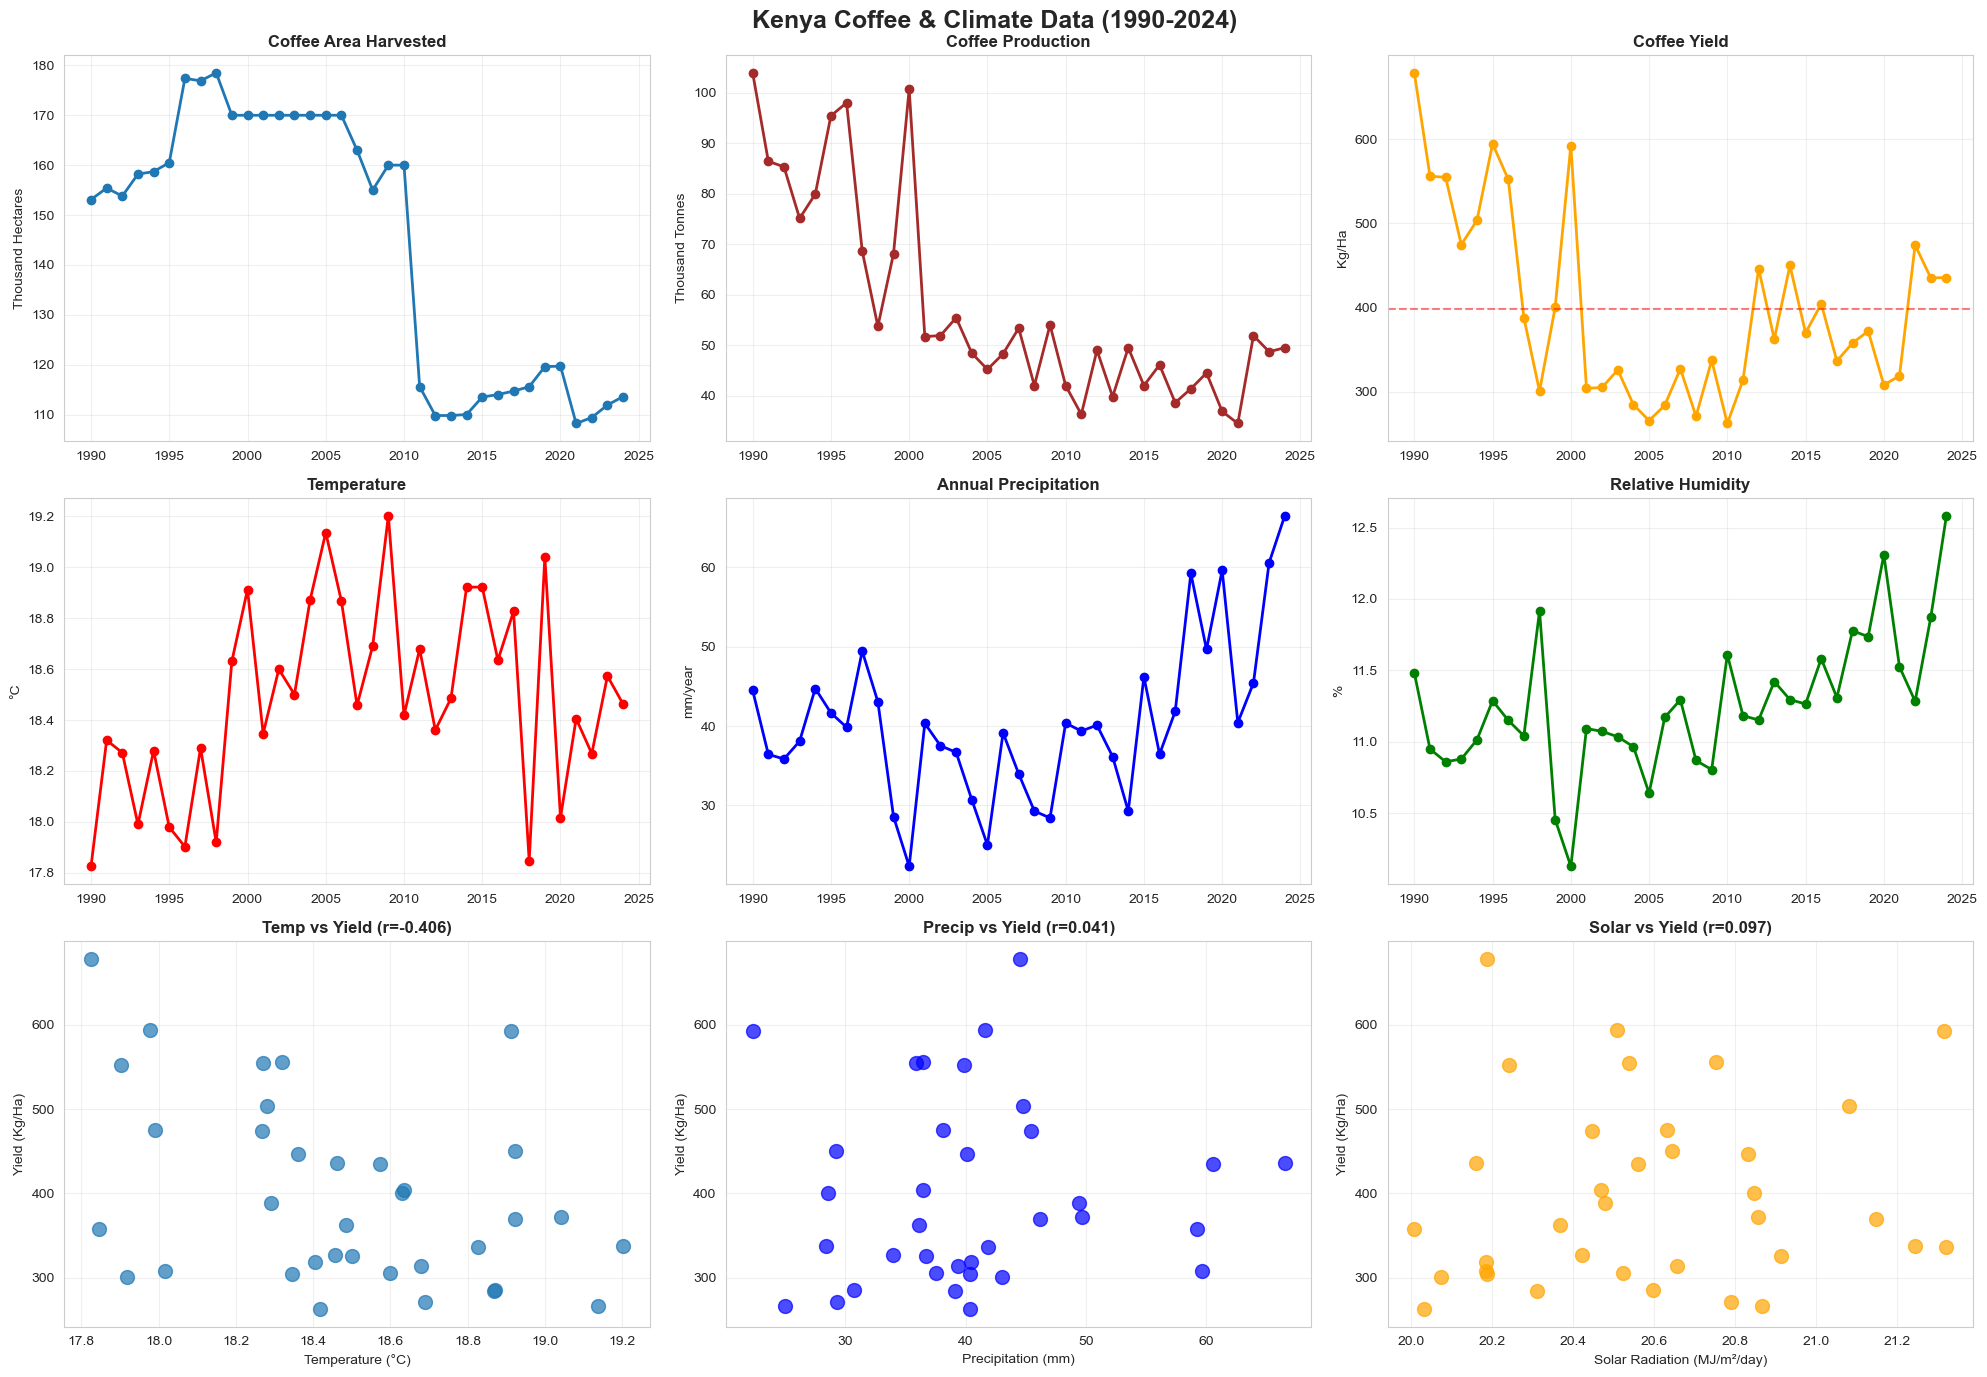

In [24]:
# Create comprehensive visualization
if 'merged_final' in locals():
    fig, axes = plt.subplots(3, 3, figsize=(20, 14))
    fig.suptitle('Kenya Coffee & Climate Data (1990-2024)', fontsize=18, fontweight='bold')
    
    # Coffee metrics
    axes[0, 0].plot(merged_final['Year'], merged_final['Area_Ha']/1000, marker='o', linewidth=2)
    axes[0, 0].set_title('Coffee Area Harvested', fontweight='bold')
    axes[0, 0].set_ylabel('Thousand Hectares')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(merged_final['Year'], merged_final['Production_Tonnes']/1000, marker='o', linewidth=2, color='brown')
    axes[0, 1].set_title('Coffee Production', fontweight='bold')
    axes[0, 1].set_ylabel('Thousand Tonnes')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].plot(merged_final['Year'], merged_final['Yield_Kg_Ha'], marker='o', linewidth=2, color='orange')
    axes[0, 2].set_title('Coffee Yield', fontweight='bold')
    axes[0, 2].set_ylabel('Kg/Ha')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].axhline(y=merged_final['Yield_Kg_Ha'].mean(), color='red', linestyle='--', alpha=0.5)
    
    # Climate variables
    axes[1, 0].plot(merged_final['Year'], merged_final['Temperature'], marker='o', linewidth=2, color='red')
    axes[1, 0].set_title('Temperature', fontweight='bold')
    axes[1, 0].set_ylabel('°C')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(merged_final['Year'], merged_final['Precipitation'], marker='o', linewidth=2, color='blue')
    axes[1, 1].set_title('Annual Precipitation', fontweight='bold')
    axes[1, 1].set_ylabel('mm/year')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].plot(merged_final['Year'], merged_final['Humidity'], marker='o', linewidth=2, color='green')
    axes[1, 2].set_title('Relative Humidity', fontweight='bold')
    axes[1, 2].set_ylabel('%')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Relationships
    corr_temp = merged_final['Temperature'].corr(merged_final['Yield_Kg_Ha'])
    axes[2, 0].scatter(merged_final['Temperature'], merged_final['Yield_Kg_Ha'], alpha=0.7, s=100)
    axes[2, 0].set_xlabel('Temperature (°C)')
    axes[2, 0].set_ylabel('Yield (Kg/Ha)')
    axes[2, 0].set_title(f'Temp vs Yield (r={corr_temp:.3f})', fontweight='bold')
    axes[2, 0].grid(True, alpha=0.3)
    
    corr_precip = merged_final['Precipitation'].corr(merged_final['Yield_Kg_Ha'])
    axes[2, 1].scatter(merged_final['Precipitation'], merged_final['Yield_Kg_Ha'], alpha=0.7, s=100, color='blue')
    axes[2, 1].set_xlabel('Precipitation (mm)')
    axes[2, 1].set_ylabel('Yield (Kg/Ha)')
    axes[2, 1].set_title(f'Precip vs Yield (r={corr_precip:.3f})', fontweight='bold')
    axes[2, 1].grid(True, alpha=0.3)
    
    corr_solar = merged_final['Solar_Radiation'].corr(merged_final['Yield_Kg_Ha'])
    axes[2, 2].scatter(merged_final['Solar_Radiation'], merged_final['Yield_Kg_Ha'], alpha=0.7, s=100, color='orange')
    axes[2, 2].set_xlabel('Solar Radiation (MJ/m²/day)')
    axes[2, 2].set_ylabel('Yield (Kg/Ha)')
    axes[2, 2].set_title(f'Solar vs Yield (r={corr_solar:.3f})', fontweight='bold')
    axes[2, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    output_path = '/Users/dwanjiru/projects/kenya-coffee-research/reports/data_overview_1990_2024.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()